In [1]:
!pip install xgboost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop('customerID', axis=1)

y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")
print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")
print(f"Logistic Regression Accuracy (Week 4 earlier): 82.19%")

Random Forest Accuracy: 79.21%
XGBoost Accuracy: 79.84%
Logistic Regression Accuracy (Week 4 earlier): 82.19%


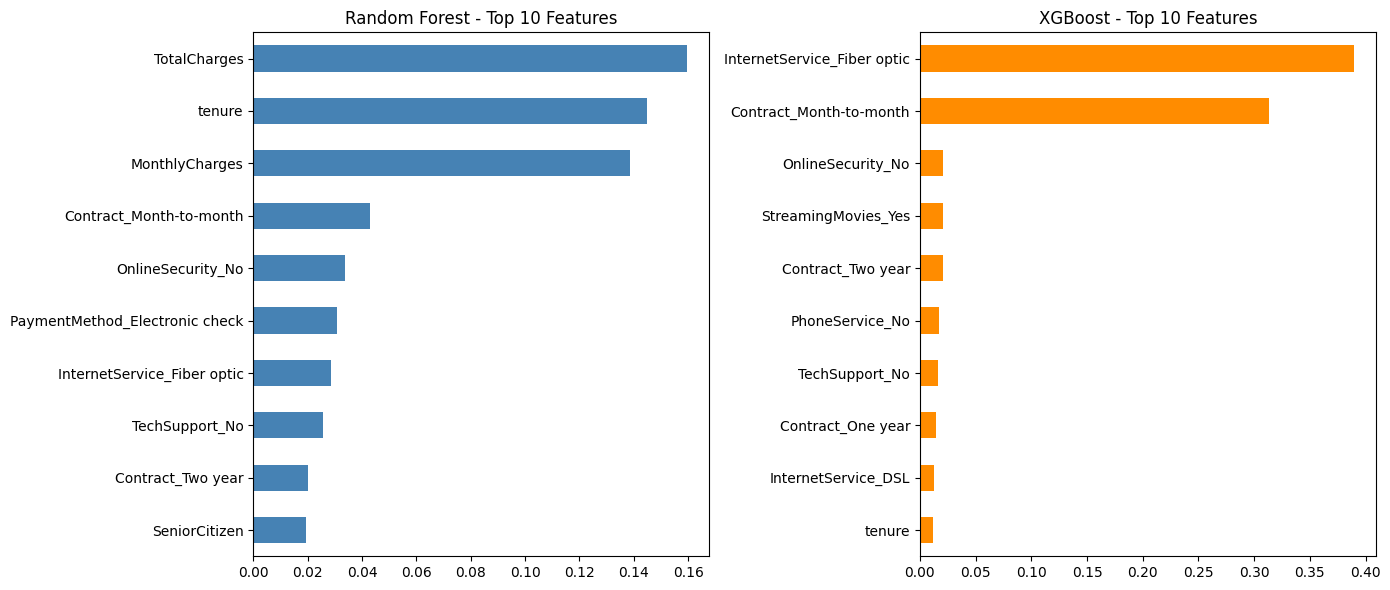

In [4]:
# Feature names nikalo preprocessor se
feature_names = (numerical_cols +
    list(rf_pipeline.named_steps['preprocessing'].named_transformers_['cat'].get_feature_names_out(categorical_cols)))

# Random Forest importances
rf_importances = rf_pipeline.named_steps['model'].feature_importances_
# XGBoost importances
xgb_importances = xgb_pipeline.named_steps['model'].feature_importances_

# Top 10 features har model ke liye
rf_top10 = pd.Series(rf_importances, index=feature_names).sort_values(ascending=False).head(10)
xgb_top10 = pd.Series(xgb_importances, index=feature_names).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_top10.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest - Top 10 Features')
axes[0].invert_yaxis()

xgb_top10.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost - Top 10 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png')
plt.show()

In [5]:
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Metric': ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy'],
    'Score': ['82.19%', '77%', f'{rf_accuracy:.2%}', f'{xgb_accuracy:.2%}']
})
print(comparison_table)

                 Model    Metric   Score
0  Logistic Regression  Accuracy  82.19%
1        Decision Tree  Accuracy     77%
2        Random Forest  Accuracy  79.21%
3              XGBoost  Accuracy  79.84%


Random Forest aur XGBoost dono ensemble methods hain jo multiple decision trees combine karte hain, lekin unka combine karne ka tareeqa alag hai. Random Forest "bagging" use karta hai — kayi trees ko independently, parallel mein, random data samples par train karta hai aur unke predictions ka average leta hai, jisse overfitting kam hoti hai. XGBoost "boosting" use karta hai — trees ko sequentially banata hai, jahan har naya tree pichle tree ki galtiyon ko theek karne ki koshish karta hai, isliye ye zyada accurate ho sakta hai lekin overfitting ka khatra bhi zyada hota hai. Is dataset par dono ensemble models (RF: 79.21%, XGBoost: 79.84%) simple Logistic Regression (82.19%) se peeche rahe, jo dikhata hai ke complex models hamesha behtar nahi hote — chhote ya kam-complex datasets mein simple models bhi jeet sakte hain.